In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy.stats import poisson
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import log_loss, brier_score_loss, accuracy_score
import xgboost as xgb
import joblib
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_style('whitegrid')

## Cargar datos

In [6]:
df = pd.read_csv('E0.csv')
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df = df.sort_values('Date').reset_index(drop=True)
print(f"Partidos: {len(df)}")
df.head()

Partidos: 380


,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,AvgC<2.5,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA
0,E0,2023-08-11,20:00,Burnley,Man City,0,3,A,0,2,...,2.28,1.50,1.95,1.98,1.95,1.97,NaN,NaN,1.92,1.95
1,E0,2023-08-12,12:30,Arsenal,Nott'm Forest,2,1,H,2,0,...,2.63,-2.00,1.95,1.98,1.93,1.97,2.01,2.09,1.95,1.92
2,E0,2023-08-12,15:00,Bournemouth,West Ham,1,1,D,0,0,...,2.12,0.00,2.02,1.91,2.01,1.92,2.06,1.96,1.96,1.91
3,E0,2023-08-12,15:00,Brighton,Luton,4,1,H,1,0,...,2.48,-1.75,2.01,1.92,2.00,1.91,2.14,1.93,2.00,1.86
4,E0,2023-08-12,15:00,Everton,Fulham,0,1,A,0,0,...,1.71,-0.25,2.06,1.87,2.04,1.88,2.08,1.99,1.98,1.88


## EDA

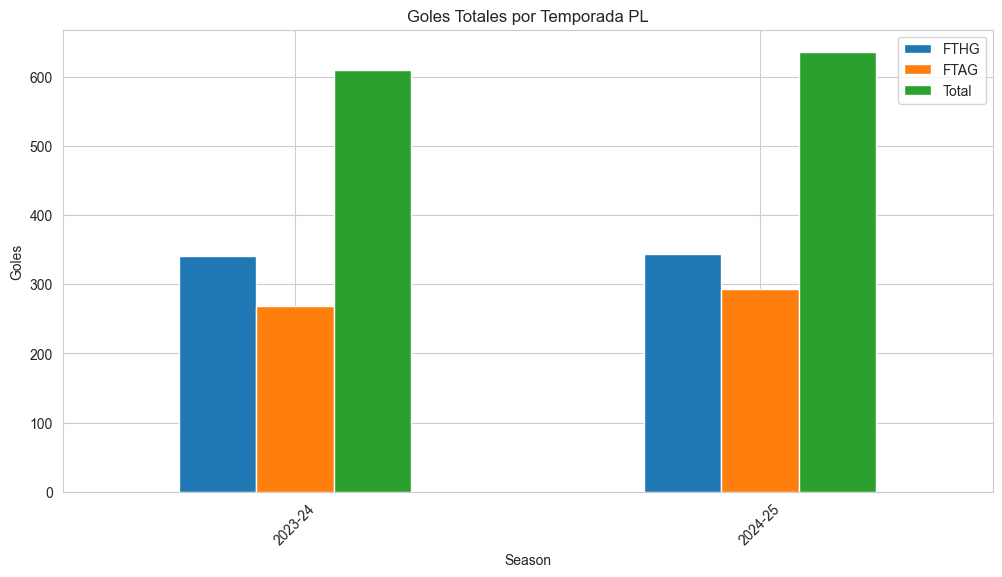

In [7]:
df['Season'] = df['Date'].dt.year.astype(str) + '-' + (df['Date'].dt.year % 100 + 1).astype(str)
goles = df.groupby('Season')[['FTHG', 'FTAG']].sum()
goles['Total'] = goles['FTHG'] + goles['FTAG']
goles.plot(kind='bar', figsize=(12,6))
plt.title('Goles Totales por Temporada PL')
plt.ylabel('Goles')
plt.xticks(rotation=45)
plt.show()

### Goles esperados

In [8]:

goal_model_data = pd.concat([
    df[['HomeTeam','AwayTeam','FTHG']].assign(home=1).rename(
        columns={'HomeTeam':'team', 'AwayTeam':'opponent','FTHG':'goals'}),
    df[['AwayTeam','HomeTeam','FTAG']].assign(home=0).rename(
        columns={'AwayTeam':'team', 'HomeTeam':'opponent','FTAG':'goals'})
])

poisson_model = smf.glm('goals ~ home + team + opponent', 
                       data=goal_model_data, 
                       family=sm.families.Poisson()).fit()
print(poisson_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  goals   No. Observations:                  760
Model:                            GLM   Df Residuals:                      720
Model Family:                 Poisson   Df Model:                           39
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1135.3
Date:                Wed, 15 Apr 2026   Deviance:                       749.08
Time:                        11:05:13   Pearson chi2:                     634.
No. Iterations:                     5   Pseudo R-squ. (CS):             0.2174
Covariance Type:            nonrobust                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

## Feature engineering

In [10]:
# Forma reciente
def rolling_form(df, n=5):
    df = df.sort_values('Date').copy()
    
    df['FTR_num'] = df['FTR'].map({'H': 1.0, 'D': 0.5, 'A': 0.0})
    
    # Forma reciente (últimos 5 partidos)
    df['HomeForm'] = (df.groupby('HomeTeam')['FTR_num']
                     .rolling(n, min_periods=1).mean()
                     .shift(1).reset_index(0,drop=True))
    
    df['AwayForm'] = (df.groupby('AwayTeam')['FTR_num']
                     .rolling(n, min_periods=1).mean()
                     .shift(1).reset_index(0,drop=True))
    
    # Limpiar columna temporal
    df = df.drop('FTR_num', axis=1)
    return df

df = rolling_form(df)

# H2H simple
def h2h_feature(df):
    df = df.sort_values('Date')
    h2h = []
    for idx, row in df.iterrows():
        mask = ((df['HomeTeam']==row['HomeTeam']) & 
                (df['AwayTeam']==row['AwayTeam'])) | \
               ((df['HomeTeam']==row['AwayTeam']) & 
                (df['AwayTeam']==row['HomeTeam']))
        prev = df[mask].iloc[:idx]
        if len(prev) > 0:
            h2h.append(prev['FTR_num'].iloc[-1] if 'FTR_num' in prev.columns else 0.5)
        else:
            h2h.append(0.5)
    df['H2H'] = h2h
    return df

df = h2h_feature(df)

# Odds
odds_cols = ['B365H', 'B365D', 'B365A']
df['AvgOddsH'] = df[odds_cols[0]].fillna(df[odds_cols[0]].mean())
df['AvgOddsD'] = df[odds_cols[1]].fillna(df[odds_cols[1]].mean())
df['AvgOddsA'] = df[odds_cols[2]].fillna(df[odds_cols[2]].mean())

# Target
df['Result'] = df['FTR'].map({'H':0, 'D':1, 'A':2})

print("Features creadas:")
print(df[['HomeForm', 'AwayForm', 'H2H', 'AvgOddsH', 'AvgOddsD', 'AvgOddsA', 'Result']].head())
print(f"\nDistribución Resultados: {df['Result'].value_counts(normalize=True).round(3)}")

Features creadas:
   HomeForm  AwayForm  H2H  AvgOddsH  AvgOddsD  AvgOddsA  Result
0       0.2       1.0  0.5      8.00       5.5      1.33       2
1       NaN       0.4  0.5      1.18       7.0     15.00       0
2       0.7       0.7  0.5      2.70       3.4      2.55       1
3       0.5       0.5  0.5      1.33       5.5      9.00       0
4       0.8       0.8  0.5      2.20       3.4      3.30       2

Distribución Resultados: Result
0    0.461
2    0.324
1    0.216
Name: proportion, dtype: float64


## Preprocesamiento

In [11]:
le_home = LabelEncoder()
le_away = LabelEncoder()
df['HomeTeamEnc'] = le_home.fit_transform(df['HomeTeam'])
df['AwayTeamEnc'] = le_away.fit_transform(df['AwayTeam'])

features = ['HomeForm', 'AwayForm', 'AvgOddsH', 'AvgOddsD', 'AvgOddsA', 
            'HomeTeamEnc', 'AwayTeamEnc']
X = df[features]
y = df['Result']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Modelo

In [12]:
xgb_model = xgb.XGBClassifier(
    objective='multi:softprob', num_class=3, 
    n_estimators=200, learning_rate=0.1, max_depth=6,
    random_state=42
)
xgb_model.fit(X_train, y_train)

y_pred_proba = xgb_model.predict_proba(X_test)
y_pred = xgb_model.predict(X_test)

## Métricas

In [15]:
from sklearn.metrics import accuracy_score, log_loss, classification_report
from sklearn.preprocessing import label_binarize
import numpy as np

acc = accuracy_score(y_test, y_pred)
logloss = log_loss(y_test, y_pred_proba)

y_test_bin = label_binarize(y_test, classes=[0,1,2])
brier_multi = np.mean(np.sum((y_pred_proba - y_test_bin)**2, axis=1))

print(f"✅ Accuracy: {acc:.3f} (objetivo ~65%)")
print(f"📊 Log Loss: {logloss:.3f}")
print(f"🎯 Brier Score (multiclase): {brier_multi:.3f}")
print("\n📈 Report Detallado:")
print(classification_report(y_test, y_pred, 
                          target_names=['Victoria Local', 'Empate', 'Victoria Visitante']))


probs_df = pd.DataFrame({
    'P(H)': y_pred_proba[:,0],
    'P(D)': y_pred_proba[:,1], 
    'P(A)': y_pred_proba[:,2],
    'Pred': pd.Categorical.from_codes(y_pred, categories=['H','D','A']),
    'Real': pd.Categorical.from_codes(y_test.values, categories=['H','D','A'])
})
print("\nEjemplo probabilidades:")
probs_df.head()

✅ Accuracy: 0.513 (objetivo ~65%)
📊 Log Loss: 1.643
🎯 Brier Score (multiclase): 0.754

📈 Report Detallado:
                    precision    recall  f1-score   support

    Victoria Local       0.65      0.69      0.67        35
            Empate       0.20      0.12      0.15        16
Victoria Visitante       0.45      0.52      0.48        25

          accuracy                           0.51        76
         macro avg       0.43      0.44      0.43        76
      weighted avg       0.49      0.51      0.50        76


Ejemplo probabilidades:


,P(H),P(D),P(A),Pred,Real
0,0.393321,0.009503,0.597176,A,D
1,0.011359,0.248088,0.740554,A,H
2,0.984779,0.014987,0.000234,H,A
3,0.996244,0.001742,0.002014,H,H
4,0.051003,0.836768,0.112230,D,H


## Guardar modelo

In [17]:
joblib.dump(xgb_model, 'model.joblib')
joblib.dump(le_home, 'home_encoder.joblib')
joblib.dump(le_away, 'away_encoder.joblib')
print("¡Modelos guardados!")

¡Modelos guardados!
